# EDA — HuffPost Category Classification

This notebook performs Exploratory Data Analysis (EDA) for a multi-class text classification problem.

- Target label: `category`
- Input text: `headline` + `[SEP]` + `short_description` → derived `text`

The goal is to produce the plots/tables needed to make preprocessing + feature extraction decisions, then migrate stable logic into `src/pipelines/`.

## 1. Setup & Imports (EDA Stack)

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display / plotting defaults
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

# Resolve repo root robustly (works whether cwd is repo root or notebooks/)
_candidates = [Path.cwd().resolve(), Path.cwd().resolve().parent, Path.cwd().resolve().parent.parent]
REPO_ROOT = None
for _p in _candidates:
    if (_p / "config" / "huffpost_category_text.json").exists():
        REPO_ROOT = _p
        break
assert REPO_ROOT is not None, "Could not locate repo root (missing config/huffpost_category_text.json)"

CONFIG_PATH = REPO_ROOT / "config" / "huffpost_category_text.json"
assert CONFIG_PATH.exists(), f"Config not found: {CONFIG_PATH}"

# Save key EDA artifacts (figures + tables) here (kept out of staged data/)
ARTIFACT_DIR = REPO_ROOT / "notebooks" / "eda_artifacts" / "huffpost"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    """Save the current matplotlib figure to the EDA artifact folder."""

    safe = "".join(ch if ch.isalnum() or ch in ("-", "_", ".") else "_" for ch in name)
    out_path = ARTIFACT_DIR / safe
    plt.savefig(out_path, dpi=150, bbox_inches="tight")

## 2. Load Dataset (JSONL) + Quick Sanity Checks

In [2]:
with CONFIG_PATH.open("r", encoding="utf-8") as f:
    cfg = json.load(f)

schema_cfg = cfg["schema"]
paths_cfg = cfg["paths"]
text_cfg = cfg["text_assembly"]

# Visualization palette (driven by config)
COLOR_PALETTE = cfg.get("visualization", {}).get("color_palette")
if not COLOR_PALETTE:
    COLOR_PALETTE = [
#c6d4e1",  # light blue-grey
        "#9bbcd4",  # soft blue
        "#6fa3c7",  # medium blue
        "#4a8ab8",  # strong blue
        "#2f6fa1",  # deep blue
        "#1f4f75",  # navy
        "#d3d3d3",  # light grey
        "#a9a9a9",  # medium grey
        "#696969",  # dark grey
    ]
sns.set_palette(COLOR_PALETTE)

raw_path = REPO_ROOT / paths_cfg["raw_dir"] / paths_cfg["raw_filename"]
assert raw_path.exists(), f"Raw dataset not found: {raw_path}"

label_col = schema_cfg["label_col"]
headline_col = schema_cfg["headline_col"]
description_col = schema_cfg["description_col"]
text_col = schema_cfg["text_col"]

separator = text_cfg["separator"]

df_raw = pd.read_json(raw_path, lines=True)

print("Raw shape:", df_raw.shape)
df_raw.head(3)

Raw shape: (200853, 6)


,category,headline,authors,link,short_description,date
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,Melissa Jeltsen,https://www.huffingtonpost.com/entry/texas-ama...,She left her husband. He killed their children...,2018-05-26
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Andy McDonald,https://www.huffingtonpost.com/entry/will-smit...,Of course it has a song.,2018-05-26
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,Ron Dicker,https://www.huffingtonpost.com/entry/hugh-gran...,The actor and his longtime girlfriend Anna Ebe...,2018-05-26


In [3]:
required_cols = [label_col, headline_col, description_col]
missing = [c for c in required_cols if c not in df_raw.columns]
assert not missing, f"Missing required columns: {missing}"

df_raw[required_cols].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200853 entries, 0 to 200852
Data columns (total 3 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   category           200853 non-null  object
 1   headline           200853 non-null  object
 2   short_description  200853 non-null  object
dtypes: object(3)
memory usage: 4.6+ MB


## 3. Schema & Type Fixes (Parsing Dates, Categoricals, Text)

In [4]:
df = df_raw.copy()

# Ensure expected columns are strings where possible
for col in [label_col, headline_col, description_col]:
    if col in df.columns:
        df[col] = df[col].astype("string")

# Parse optional date column if present
if "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce", utc=True)

df[[label_col, headline_col, description_col]].head(3)

,category,headline,short_description
0,CRIME,There Were 2 Mass Shootings In Texas Last Week...,She left her husband. He killed their children...
1,ENTERTAINMENT,Will Smith Joins Diplo And Nicky Jam For The 2...,Of course it has a song.
2,ENTERTAINMENT,Hugh Grant Marries For The First Time At Age 57,The actor and his longtime girlfriend Anna Ebe...


## 4. Target/Label Definition

In [5]:
target = label_col
print("Target column:", target)
print("# unique categories:", df[target].nunique(dropna=True))

df[target].value_counts(dropna=False).head(10)

Target column: category
# unique categories: 41


category
POLITICS          32739
WELLNESS          17827
ENTERTAINMENT     16058
TRAVEL             9887
STYLE & BEAUTY     9649
PARENTING          8677
HEALTHY LIVING     6694
QUEER VOICES       6314
FOOD & DRINK       6226
BUSINESS           5937
Name: count, dtype: Int64

## 5. Missing Data Analysis + Visualizations

In [6]:
missing_counts = df[[label_col, headline_col, description_col]].isna().sum().sort_values(ascending=False)
missing_pct = (missing_counts / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary

,missing_count,missing_pct
category,0,0.0
headline,0,0.0
short_description,0,0.0


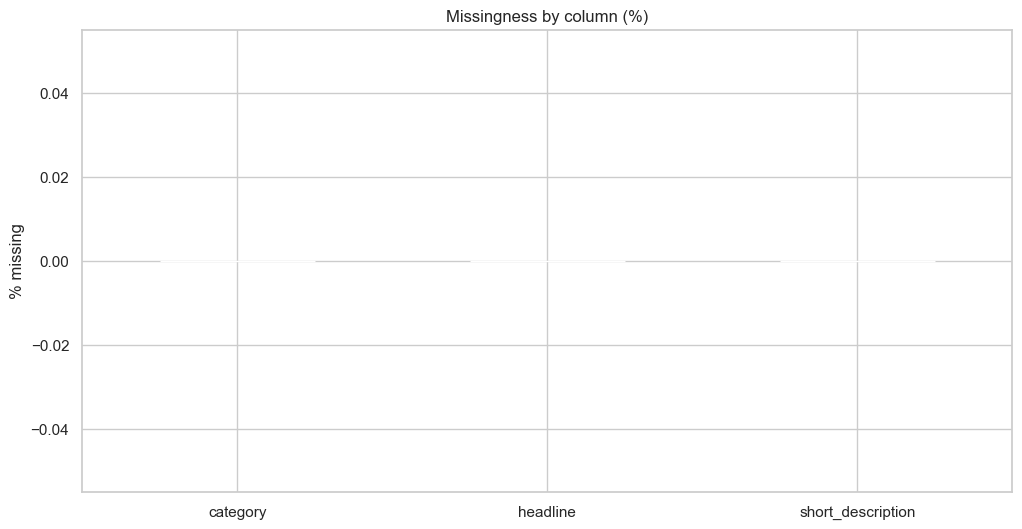

In [7]:
ax = missing_summary.sort_values("missing_pct", ascending=False)["missing_pct"].plot(
    kind="bar", color=COLOR_PALETTE[3]
 )
ax.set_title("Missingness by column (%)")
ax.set_ylabel("% missing")
plt.xticks(rotation=0)
savefig("missingness_by_column_pct.png")
plt.show()

## 6. Duplicate/Invalid Row Checks

In [8]:
def normalize_whitespace(text: str) -> str:
    """Normalize whitespace for consistent text analysis."""

    return " ".join(text.split())


def combine_text_rows(frame: pd.DataFrame) -> pd.Series:
    """Create combined `text` from headline and short description."""

    headline = frame[headline_col].fillna(text_cfg["null_headline"]).astype("string")
    desc = frame[description_col].fillna(text_cfg["null_description"]).astype("string")

    combined = headline.str.cat(desc, sep=separator)

    if text_cfg.get("normalize_whitespace", True):
        combined = combined.fillna("").map(lambda s: normalize_whitespace(str(s)))

    if text_cfg.get("strip", True):
        combined = combined.str.strip()

    return combined


df[text_col] = combine_text_rows(df)

empty_text_mask = df[text_col].fillna("").str.len() < int(text_cfg.get("min_text_length", 1))
print("Empty/too-short combined text rows:", int(empty_text_mask.sum()))

dup_mask = df[text_col].duplicated(keep=False)
print("Rows with duplicate combined text:", int(dup_mask.sum()))

# Show the most frequent duplicate texts (truncated)
dup_counts = df.loc[dup_mask, text_col].value_counts().head(10)
dup_counts

Empty/too-short combined text rows: 0
Rows with duplicate combined text: 697


text
Watch The Top 9 YouTube Videos Of The Week[SEP]If you're looking to see the most popular YouTube videos of the week, look no further. Once again, we're bringing you the                                          46
The Funniest Tweets From Women This Week[SEP]                                                                                                                                                                     33
The 20 Funniest Tweets From Women This Week[SEP]The ladies of Twitter never fail to brighten our days with their brilliant ― but succinct ― wisdom. Each week, HuffPost Women                                     30
Best Parenting Tweets: What Moms And Dads Said On Twitter This Week[SEP]Kids may say the darndest things, but parents tweet about them in the funniest ways. So each week, we round up the most hilarious         26
Funniest Parenting Tweets: What Moms And Dads Said On Twitter This Week[SEP]Kids may say the darndest things, but parents tweet about them in t

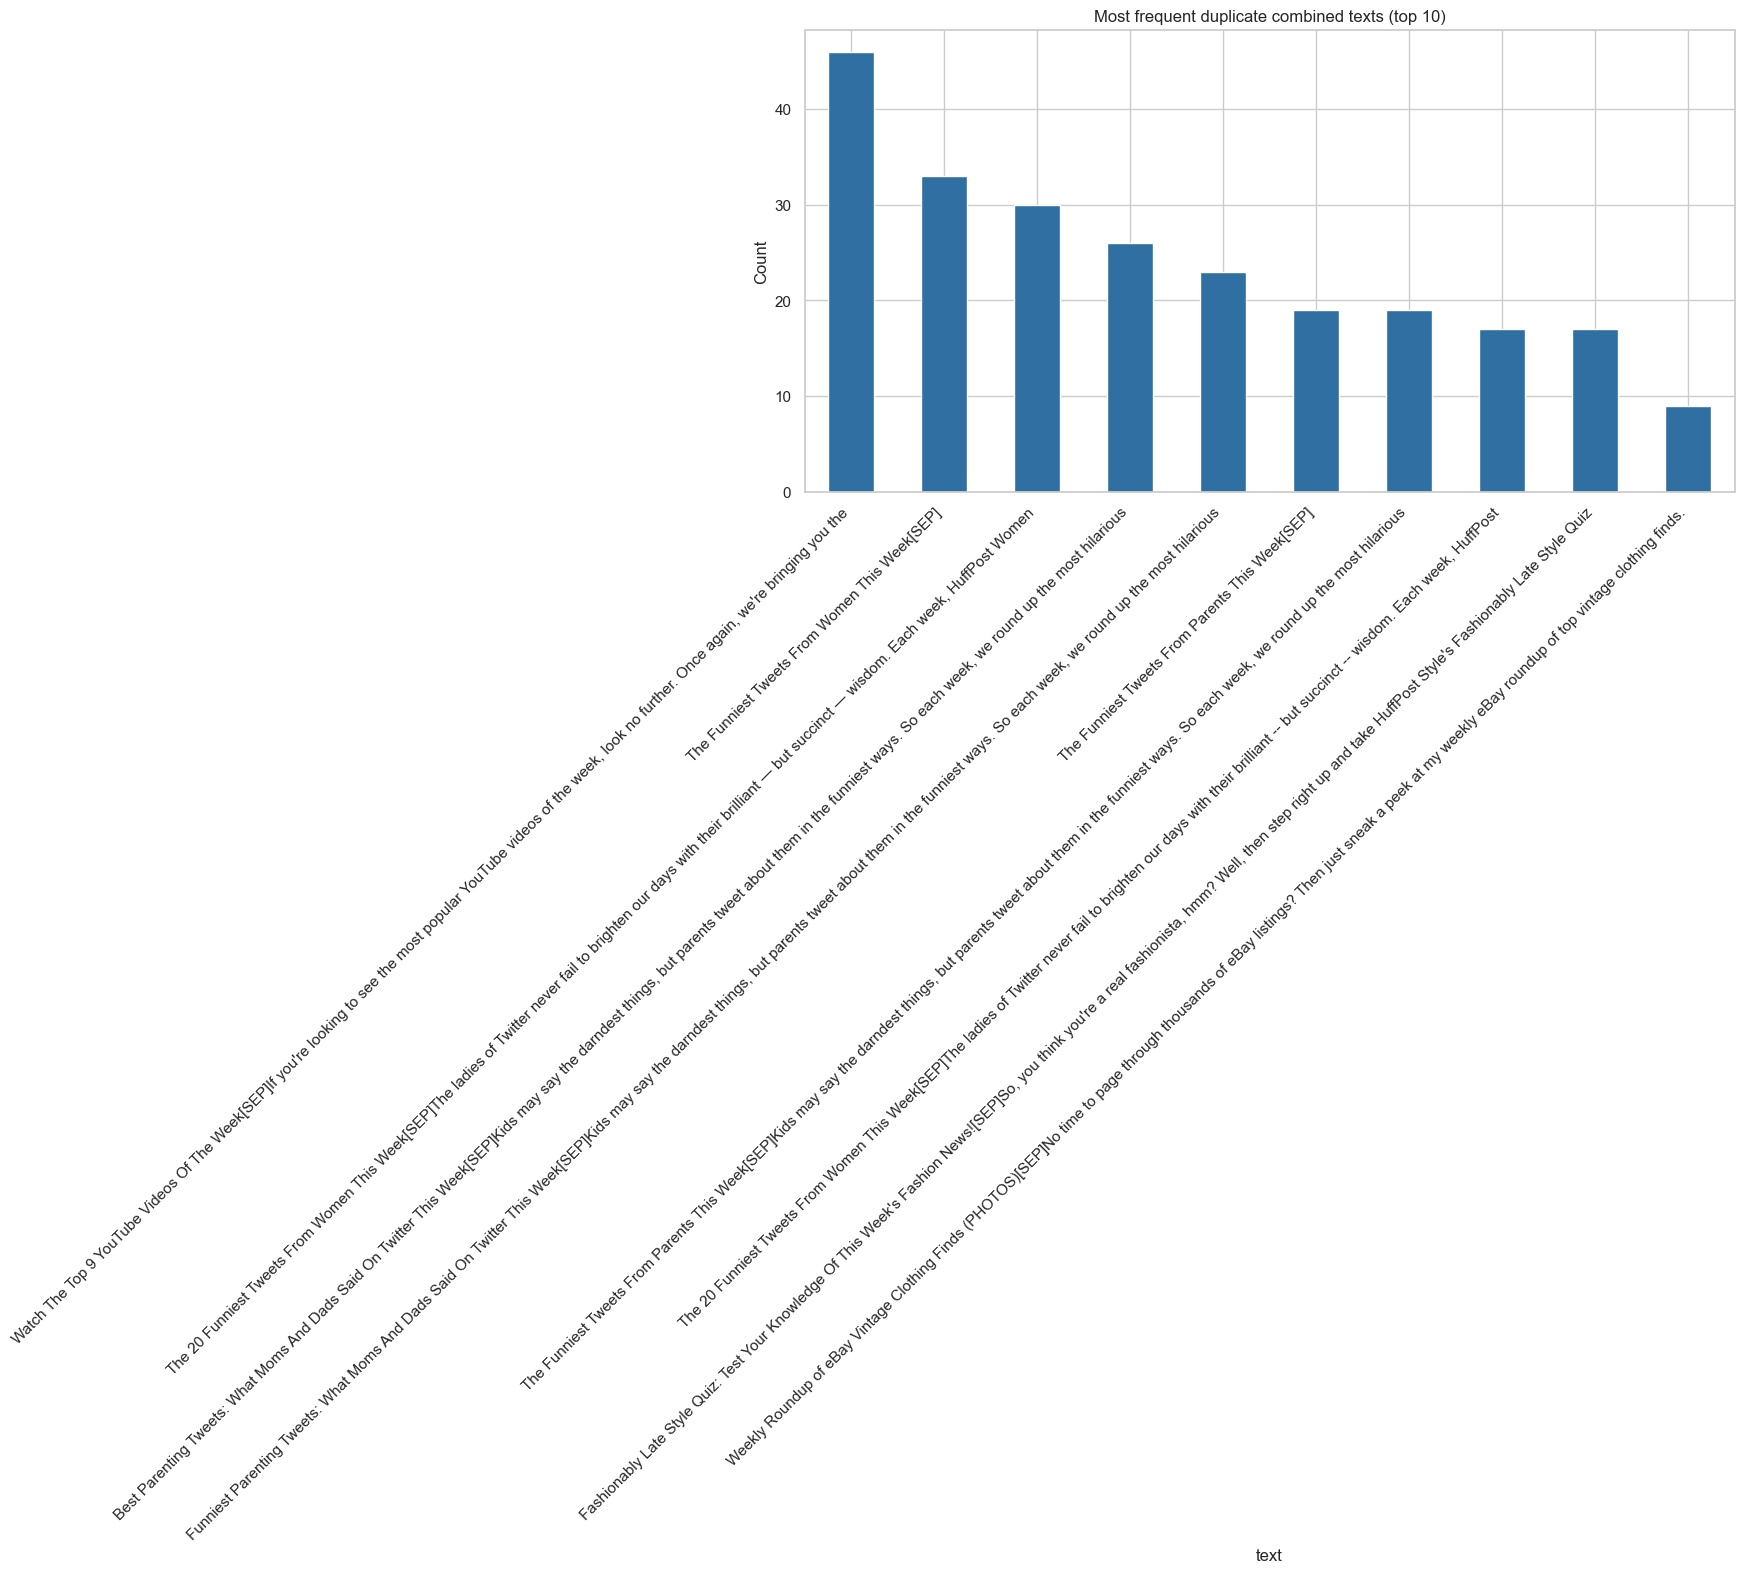

In [9]:
if not dup_counts.empty:
    ax = dup_counts.plot(kind="bar", color=COLOR_PALETTE[4])
    ax.set_title("Most frequent duplicate combined texts (top 10)")
    ax.set_ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    savefig("duplicate_texts_top10.png")
    plt.show()

## 7. Summary Statistics (Numerical + Categorical)

In [10]:
category_counts = df[target].value_counts(dropna=False)
summary = pd.DataFrame(
    {
        "count": category_counts,
        "pct": (category_counts / len(df) * 100).round(2),
    }
)
summary.head(20)

,count,pct
category,,
POLITICS,32739,16.3
WELLNESS,17827,8.88
ENTERTAINMENT,16058,7.99
TRAVEL,9887,4.92
STYLE & BEAUTY,9649,4.8
PARENTING,8677,4.32
HEALTHY LIVING,6694,3.33
QUEER VOICES,6314,3.14
FOOD & DRINK,6226,3.1


## 8. Univariate Distributions (Counts + Text Lengths)

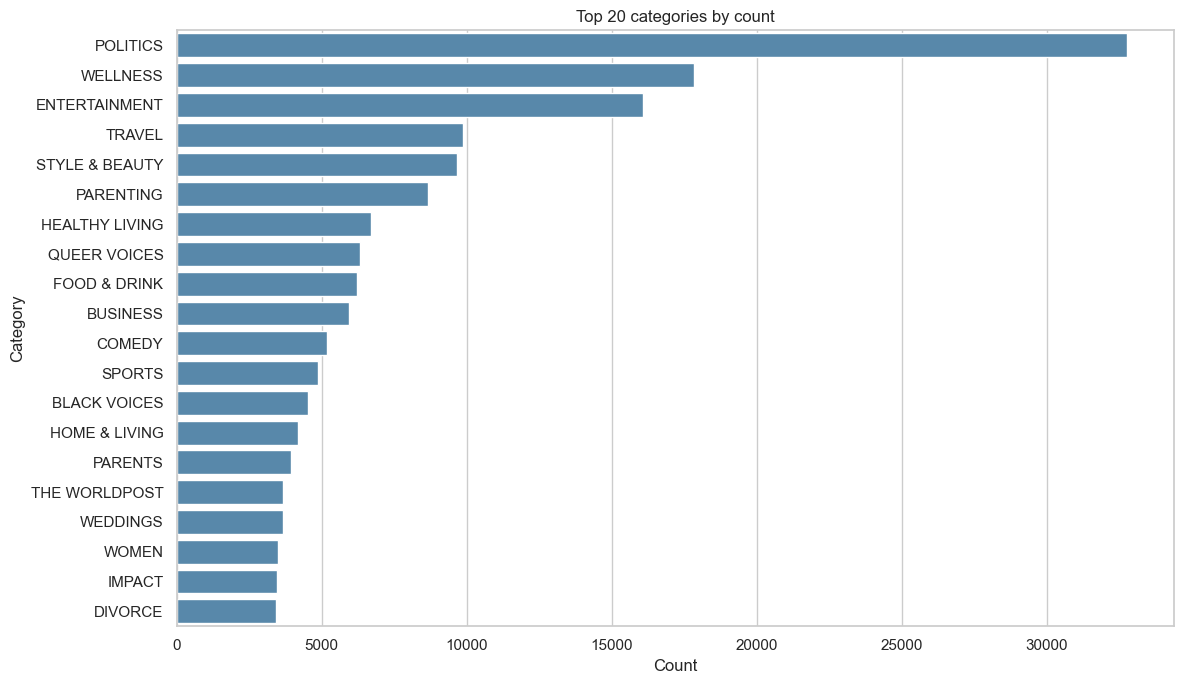

In [11]:
top_n = 20
cat_top = df[target].value_counts().head(top_n)

plt.figure(figsize=(12, 7))
sns.barplot(x=cat_top.values, y=cat_top.index, color=COLOR_PALETTE[3])
plt.title(f"Top {top_n} categories by count")
plt.xlabel("Count")
plt.ylabel("Category")
plt.tight_layout()
savefig(f"top_{top_n}_categories_by_count.png")
plt.show()

In [12]:
def text_lengths(frame: pd.DataFrame) -> pd.DataFrame:
    """Compute text length features for EDA (chars, words)."""

    text = frame[text_col].fillna("").astype("string")
    chars = text.str.len().astype(int)
    words = text.map(lambda s: len(str(s).split())).astype(int)
    return pd.DataFrame({"text_len_chars": chars, "text_len_words": words})

length_df = text_lengths(df)
df = pd.concat([df, length_df], axis=1)

df[["text_len_chars", "text_len_words"]].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).T

,count,mean,std,min,50%,90%,95%,99%,max
text_len_chars,200853.0,177.217741,79.827771,5.0,174.0,287.0,322.0,384.0,1491.0
text_len_words,200853.0,28.365023,13.908992,1.0,27.0,48.0,55.0,66.0,244.0


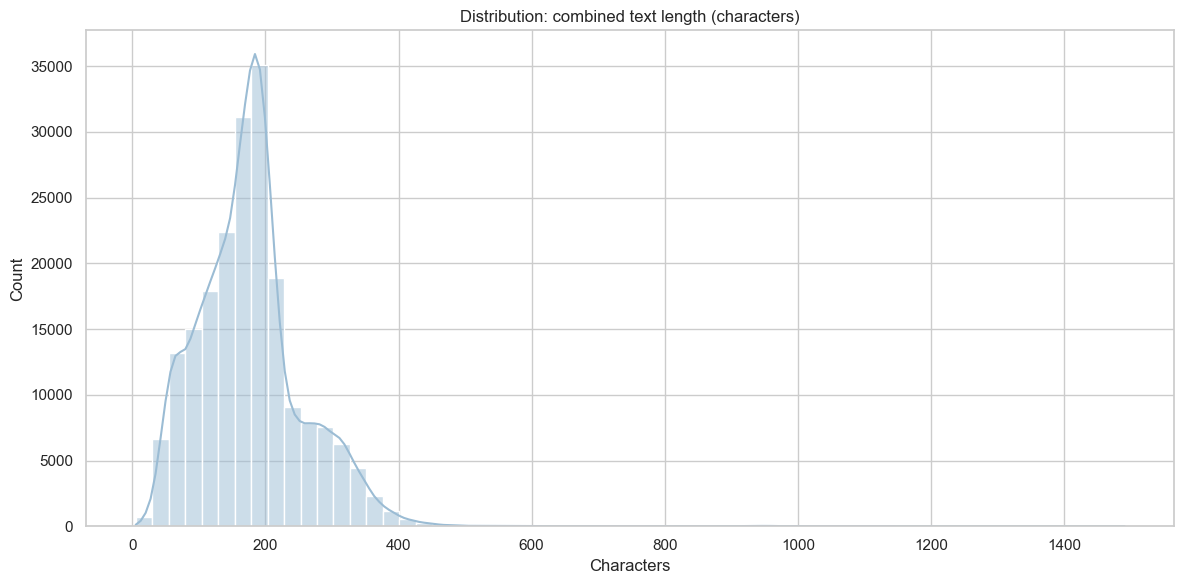

In [13]:
sns.histplot(df["text_len_chars"], bins=60, kde=True, color=COLOR_PALETTE[1])
plt.title("Distribution: combined text length (characters)")
plt.xlabel("Characters")
plt.tight_layout()
savefig("text_length_chars_hist.png")
plt.show()

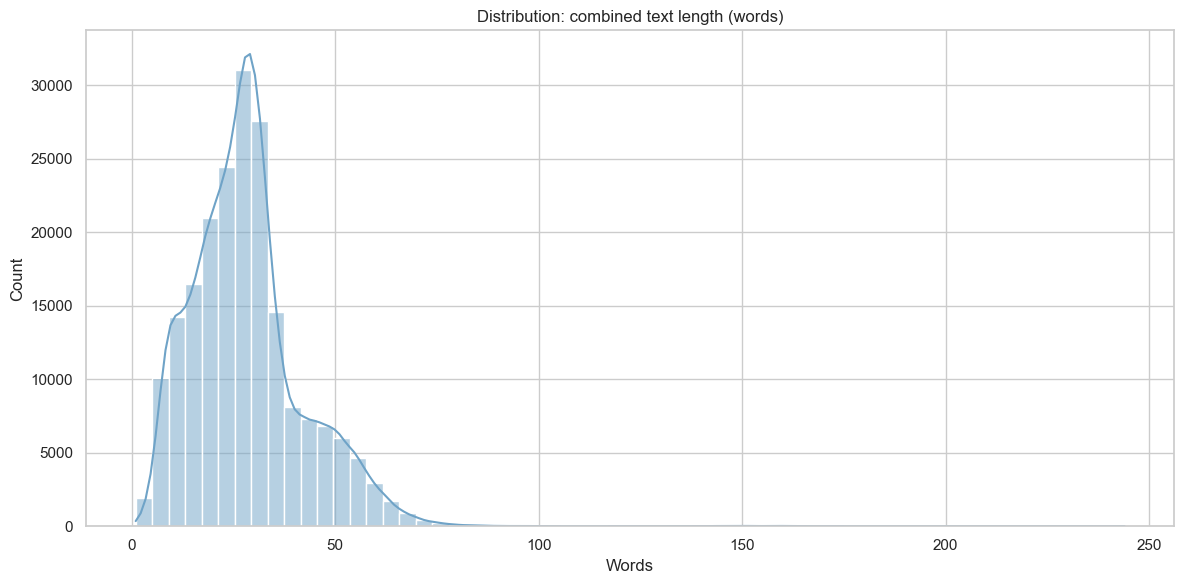

In [14]:
sns.histplot(df["text_len_words"], bins=60, kde=True, color=COLOR_PALETTE[2])
plt.title("Distribution: combined text length (words)")
plt.xlabel("Words")
plt.tight_layout()
savefig("text_length_words_hist.png")
plt.show()

## 9. Bivariate Relationships (Target vs Text Length)

C:\Users\dave\AppData\Local\Temp\ipykernel_125608\2533298785.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=subset, x=target, y="text_len_words", palette=COLOR_PALETTE)
C:\Users\dave\AppData\Local\Temp\ipykernel_125608\2533298785.py:6: UserWarning: 
The palette list has fewer values (9) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=subset, x=target, y="text_len_words", palette=COLOR_PALETTE)


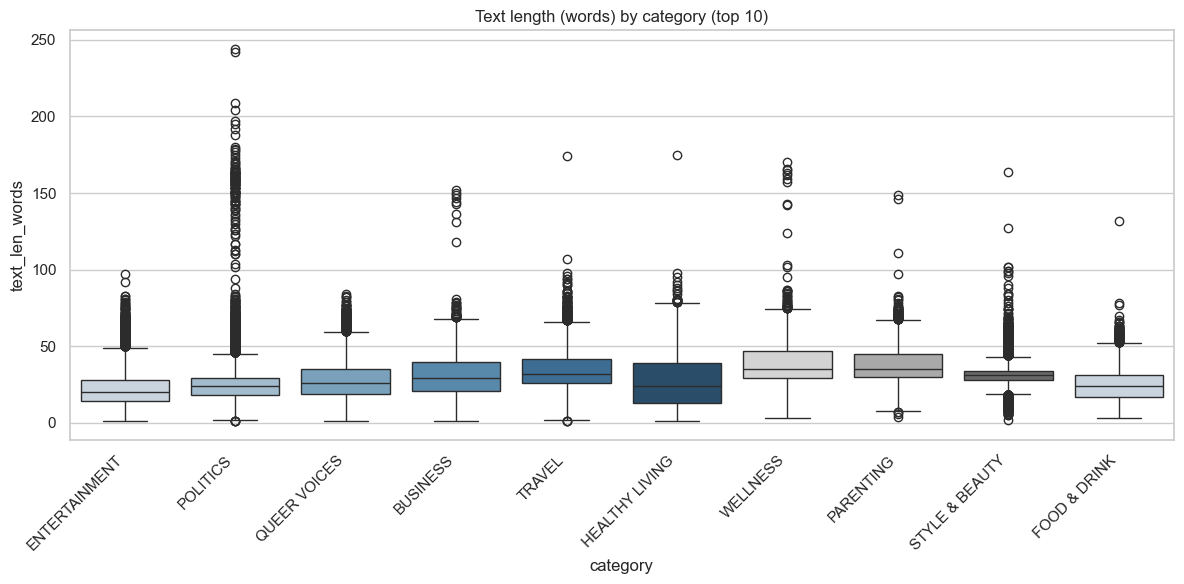

In [15]:
# Compare text lengths across the most frequent categories
cats_for_box = cat_top.index.tolist()[:10]
subset = df[df[target].isin(cats_for_box)].copy()

plt.figure(figsize=(12, 6))
sns.boxplot(data=subset, x=target, y="text_len_words", palette=COLOR_PALETTE)
plt.title("Text length (words) by category (top 10)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig("text_len_words_by_category_top10_boxplot.png")
plt.show()

## 10. Correlation & Multicollinearity (Heatmap)

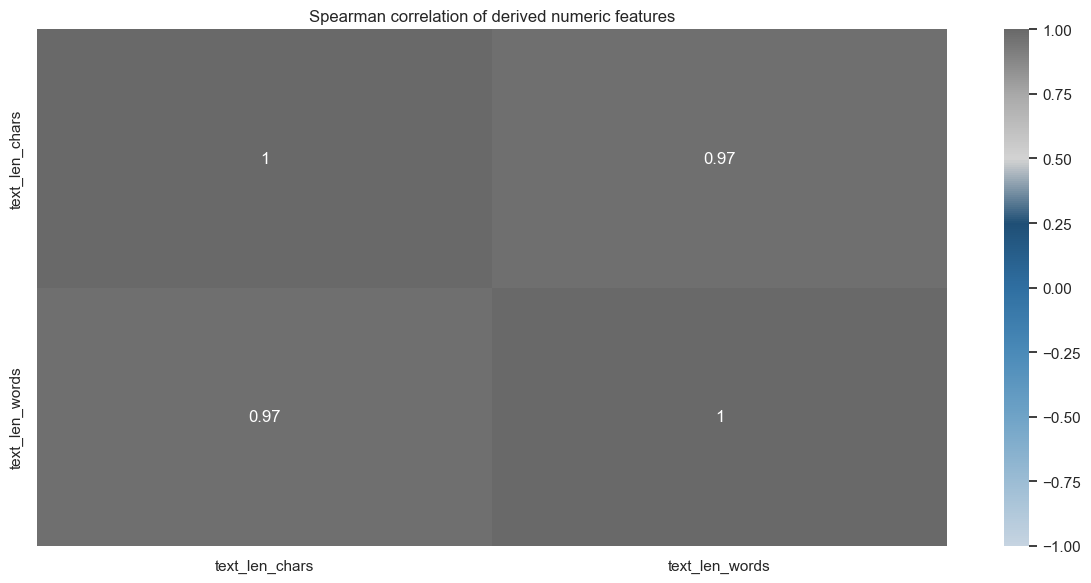

In [16]:
from matplotlib.colors import LinearSegmentedColormap

corr = df[["text_len_chars", "text_len_words"]].corr(method="spearman")
cmap = LinearSegmentedColormap.from_list("custom_palette", COLOR_PALETTE)
sns.heatmap(corr, annot=True, cmap=cmap, vmin=-1, vmax=1)
plt.title("Spearman correlation of derived numeric features")
plt.tight_layout()
savefig("derived_numeric_features_spearman_corr_heatmap.png")
plt.show()

## 11. Outlier Detection & Visualization (Text Length)

Outliers by IQR (words): 7692


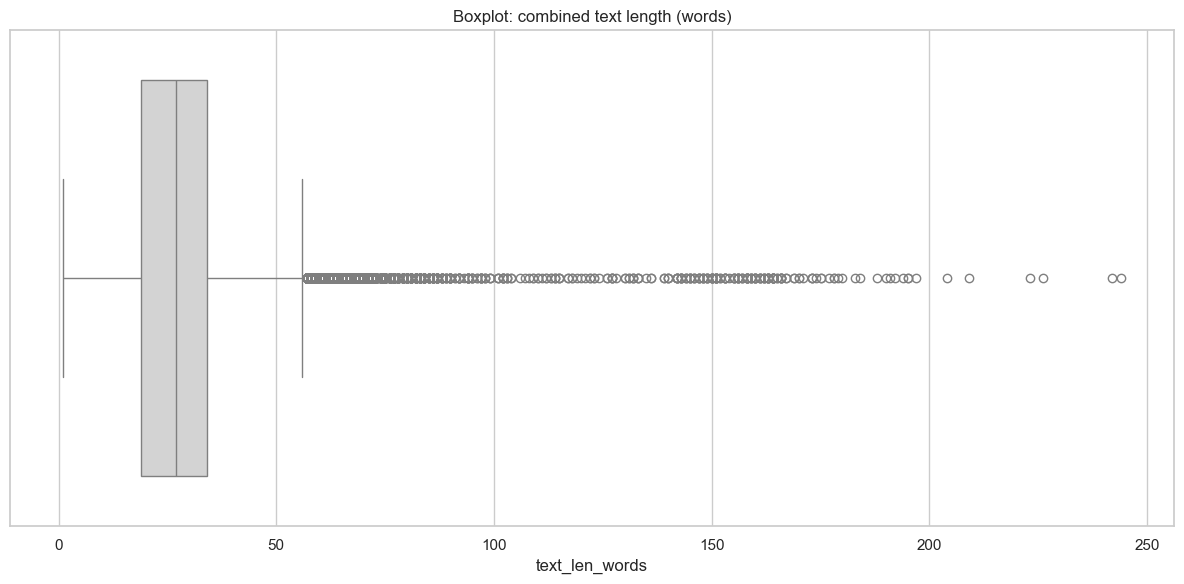

In [17]:
def iqr_outlier_mask(values: pd.Series, *, k: float = 1.5) -> pd.Series:
    """Detect outliers using the IQR rule."""

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (values < lower) | (values > upper)

out_words = iqr_outlier_mask(df["text_len_words"], k=1.5)
print("Outliers by IQR (words):", int(out_words.sum()))

sns.boxplot(x=df["text_len_words"], orient="h", color=COLOR_PALETTE[6])
plt.title("Boxplot: combined text length (words)")
plt.tight_layout()
savefig("text_len_words_boxplot.png")
plt.show()

## 12. Groupby/Segment Analysis (Category-level summaries)

In [18]:
group_stats = (
    df.groupby(target)
    .agg(
        count=(target, "size"),
        mean_words=("text_len_words", "mean"),
        p95_words=("text_len_words", lambda s: np.percentile(s, 95)),
        mean_chars=("text_len_chars", "mean"),
    )
    .sort_values("count", ascending=False)
)

group_stats.head(20)

,count,mean_words,p95_words,mean_chars
category,,,,
POLITICS,32739,25.004979,47.00,163.274779
WELLNESS,17827,38.099905,59.00,230.315084
ENTERTAINMENT,16058,21.909951,46.00,139.014261
TRAVEL,9887,33.820775,57.00,207.595024
STYLE & BEAUTY,9649,31.277024,46.00,195.508654
PARENTING,8677,37.617264,59.00,222.412009
HEALTHY LIVING,6694,27.515536,60.00,167.263968
QUEER VOICES,6314,28.908299,58.00,179.020748
FOOD & DRINK,6226,25.146964,46.75,155.723739


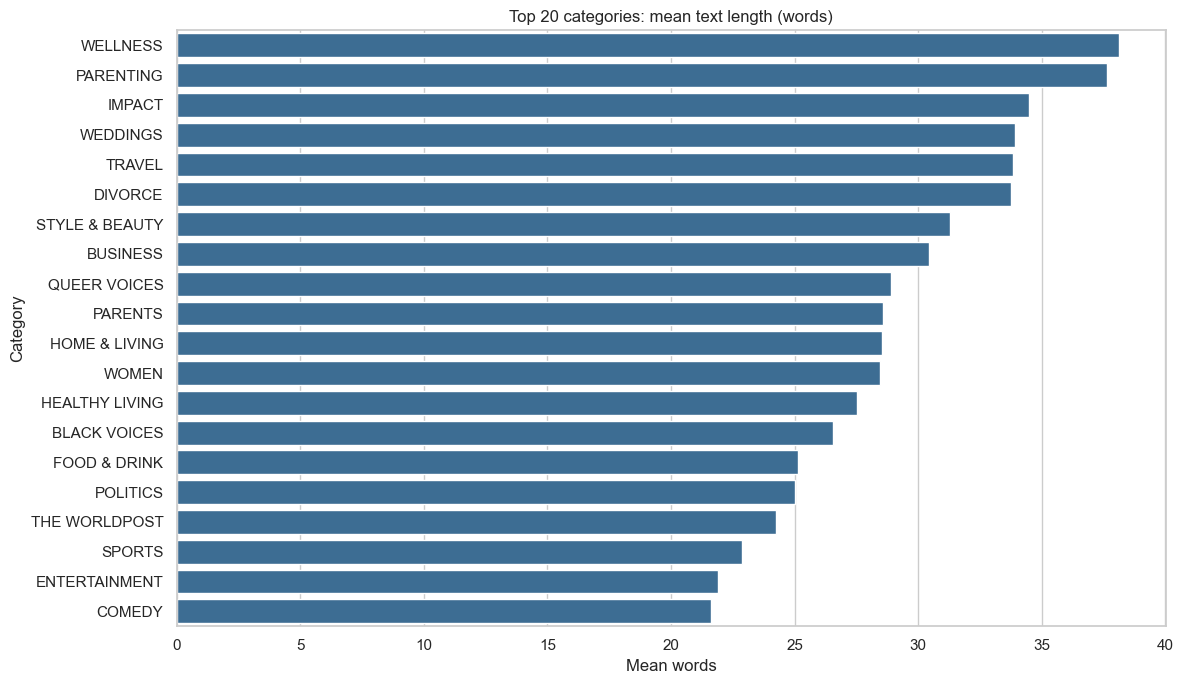

In [19]:
top_stats = group_stats.head(20).sort_values("mean_words", ascending=False)

plt.figure(figsize=(12, 7))
sns.barplot(x=top_stats["mean_words"], y=top_stats.index, color=COLOR_PALETTE[4])
plt.title("Top 20 categories: mean text length (words)")
plt.xlabel("Mean words")
plt.ylabel("Category")
plt.tight_layout()
savefig("top20_categories_mean_words.png")
plt.show()

## 13. Feature Engineering for EDA (Binning, Simple Transforms)

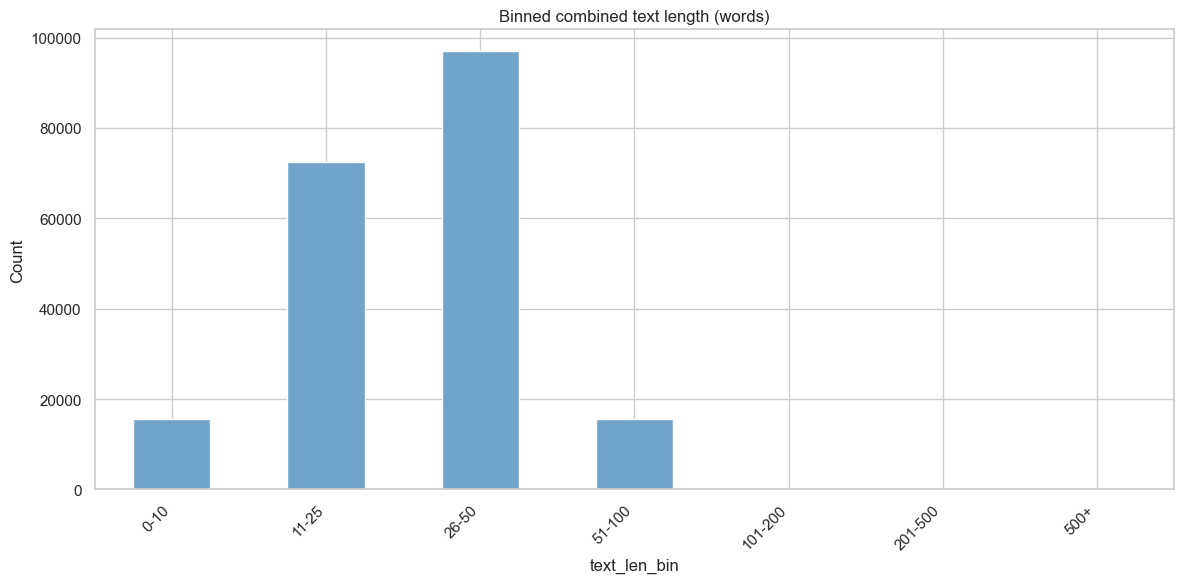

In [20]:
# Example: bin by word length to see distribution skew
bins = [0, 10, 25, 50, 100, 200, 500, np.inf]
labels = ["0-10", "11-25", "26-50", "51-100", "101-200", "201-500", "500+"]

df["text_len_bin"] = pd.cut(df["text_len_words"], bins=bins, labels=labels, include_lowest=True)

bin_counts = df["text_len_bin"].value_counts().reindex(labels)
ax = bin_counts.plot(kind="bar", color=COLOR_PALETTE[2])
ax.set_title("Binned combined text length (words)")
ax.set_ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
savefig("text_len_words_binned_counts.png")
plt.show()

## 14. Preprocessing Preview (Vectorization) + EDA Re-check

In [21]:
from sklearn.feature_extraction.text import CountVectorizer

# For token frequency, sample to keep runtime predictable
sample_n = min(20000, len(df))
df_sample = df.sample(n=sample_n, random_state=cfg["split"]["random_seed"])

vectorizer = CountVectorizer(stop_words="english", max_features=5000)
X_counts = vectorizer.fit_transform(df_sample[text_col].fillna(""))

# Sum counts across documents
term_freq = np.asarray(X_counts.sum(axis=0)).ravel()
terms = np.array(vectorizer.get_feature_names_out())

top_k = 20
idx = np.argsort(term_freq)[-top_k:]
top_terms = pd.Series(term_freq[idx], index=terms[idx]).sort_values(ascending=False)

top_terms

sep       20000
trump      1856
new        1832
people     1242
like       1210
just       1210
time       1159
photos     1096
day        1054
year       1021
life       1006
make        880
world       878
don         851
best        780
know        769
video       758
women       750
love        724
week        713
dtype: int64

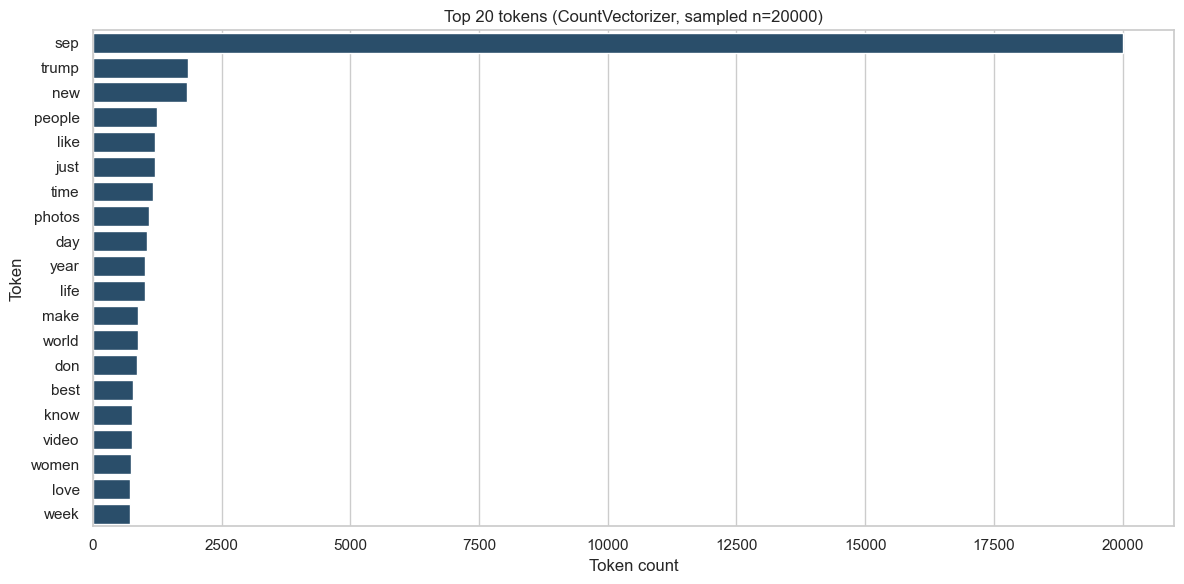

In [22]:
plt.figure(figsize=(12, 6))
sns.barplot(x=top_terms.values, y=top_terms.index, color=COLOR_PALETTE[5])
plt.title(f"Top {top_k} tokens (CountVectorizer, sampled n={sample_n})")
plt.xlabel("Token count")
plt.ylabel("Token")
plt.tight_layout()
savefig(f"top_{top_k}_tokens_countvectorizer_sample{sample_n}.png")
plt.show()

## 15. Save EDA Artifacts (Figures + Tables)

This notebook saves key figures/tables under `notebooks/eda_artifacts/` so they can be referenced later (without mixing them into staged `data/` outputs).

In [23]:
# Save key tables for later reference
missing_summary.to_csv(ARTIFACT_DIR / "missing_summary.csv")
summary.head(200).to_csv(ARTIFACT_DIR / "category_distribution_top200.csv")
group_stats.head(200).to_csv(ARTIFACT_DIR / "category_length_stats_top200.csv")

# Optional: save the top tokens from the sample vectorizer preview (if computed above)
if "top_terms" in globals():
    top_terms.to_csv(ARTIFACT_DIR / "top_tokens_countvectorizer.csv", header=["count"])

print("Saved artifacts to:", ARTIFACT_DIR)

Saved artifacts to: D:\repos\ml_classification_example\notebooks\eda_artifacts\huffpost


## Next steps

- Move `combine_text_rows()` and its normalization rules into `src/pipelines/preprocess`.
- Materialize a cleaned + split dataset under `data/02-preprocessed/`.
- Implement TF-IDF feature extraction under `data/03-features/` and run baseline experiments.